In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [24]:
data = pd.read_csv("cleaned_merged_heart_dataset.csv")
# age – Age of the patient
# sex – Sex (1 = Male, 0 = Female)
# cp – Chest Pain Type (e.g., 0–3 categories)
# trestbps – Resting Blood Pressure (in mm Hg)
# chol – Serum Cholesterol (in mg/dl)
# fbs – Fasting Blood Sugar (>120 mg/dl, 1 = True; 0 = False)
# restecg – Resting Electrocardiographic Results (0, 1, 2)
# thalachh – Maximum Heart Rate Achieved
# exang – Exercise Induced Angina (1 = Yes, 0 = No)
# oldpeak – ST Depression Induced by Exercise Relative to Rest
# slope – Slope of the Peak Exercise ST Segment (0, 1, 2)
# ca – Number of Major Vessels Colored by Fluoroscopy (0–3)
# thal – Thalassemia (0 = Normal; 1 = Fixed Defect; 2 = Reversible Defect)
# target – Heart Disease Diagnosis (1 = Disease, 0 = No Disease)


print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1888 entries, 0 to 1887
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1888 non-null   int64  
 1   sex       1888 non-null   int64  
 2   cp        1888 non-null   int64  
 3   trestbps  1888 non-null   int64  
 4   chol      1888 non-null   int64  
 5   fbs       1888 non-null   int64  
 6   restecg   1888 non-null   int64  
 7   thalachh  1888 non-null   int64  
 8   exang     1888 non-null   int64  
 9   oldpeak   1888 non-null   float64
 10  slope     1888 non-null   int64  
 11  ca        1888 non-null   int64  
 12  thal      1888 non-null   int64  
 13  target    1888 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 206.6 KB
None


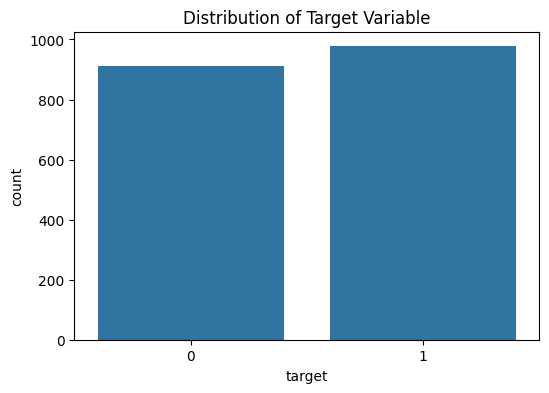

In [25]:
# Visualize the distribution of the target variable (adjust 'target' to your target column name)
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=data)
plt.title('Distribution of Target Variable')
plt.show()

In [26]:
# Step 3: Preprocessing & Splitting the Data
# Separate features and target variable (adjust 'target' as needed)
X = data.drop('target', axis=1)
y = data['target']

# Optionally, handle missing values or categorical variables here

# Split the dataset into training and testing sets (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [27]:
# Step 4: Build and Train the Random Forest Model
# Create an instance of RandomForestClassifier with default parameters
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Calculate accuracy and print classification report
initial_accuracy = accuracy_score(y_test, y_pred)
print("Initial Accuracy:", initial_accuracy)


Initial Accuracy: 0.9647266313932981


In [28]:
# Step 5: Hyperparameter Tuning with Grid Search
# Define a parameter grid to search over
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Setup GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           n_jobs=-1,
                           verbose=2)

# Fit grid search on the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score from grid search
print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Score:", grid_search.best_score_)



Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross Validation Score: 0.9689479702687251


In [31]:
# Use the best estimator to predict the test set
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

# Final accuracy with tuned hyperparameters
final_accuracy = accuracy_score(y_test, y_pred_best)
print("Final Accuracy after Hyperparameter Tuning:", final_accuracy)
print(classification_report(y_test, y_pred_best))

Final Accuracy after Hyperparameter Tuning: 0.9717813051146384
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       286
           1       0.98      0.96      0.97       281

    accuracy                           0.97       567
   macro avg       0.97      0.97      0.97       567
weighted avg       0.97      0.97      0.97       567



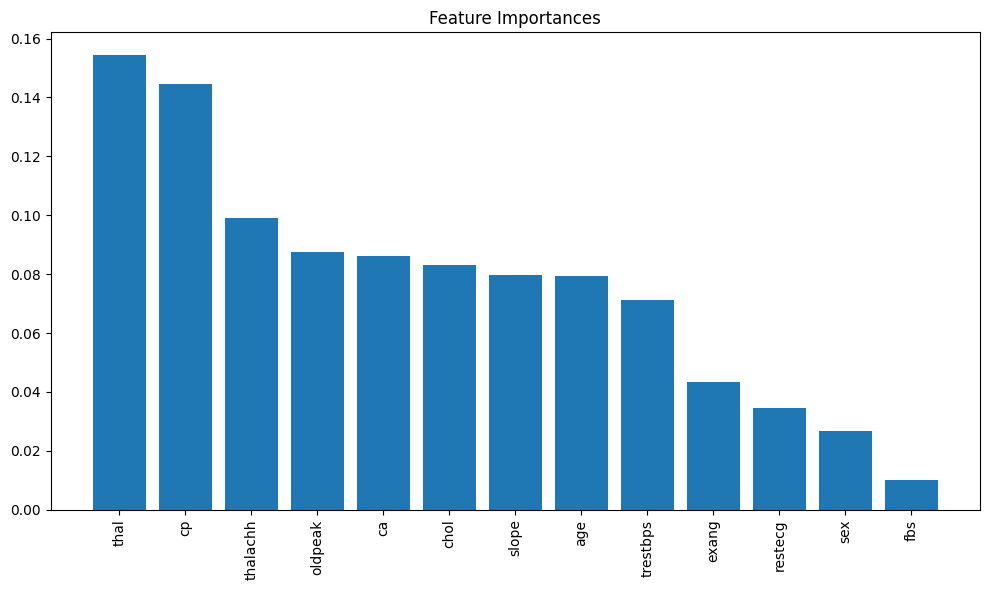

In [32]:
importances = best_rf.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importances")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), features[indices], rotation=90)
plt.tight_layout()
plt.show()